## Centroid Datamap
Temporal Mapper constructs a graph which does not have an inherent visualization. Moreover, if your data has $d$ semantic dimensions, then the graph 'naturally' lives in $d+1$ dimensions when including time.

A centroid datamap of a `TemporalMapper` is a 2d plot where each vertex is plotted on the centroid of its constituent points. 

Let's demonstrate a centroid datamap by fitting a `TemporalMapper` to a small dataset of 10,000 arXiv machine learning papers. The paper's titles and abstracts were concatenated and embedded using the sentence transformer [all-mpnet-base-v2](https://huggingface.co/sentence-transformers/all-mpnet-base-v2), and then reduced to 2D with UMAP.

In [31]:
import temporalmapper as tm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests, io
from sklearn.cluster import DBSCAN
from fast_hdbscan import HDBSCAN
import datamapplot as dmp

In [32]:
response = requests.get(
    'https://github.com/TutteInstitute/temporal-mapper/raw/refs/heads/docs/docs/data/ai_arxiv_coordinates.npy'
)
map_data = np.load(io.BytesIO(response.content))

response = requests.get(
    'https://github.com/TutteInstitute/temporal-mapper/raw/refs/heads/docs/docs/data/ai_arxiv_data.feather'
)
df = pd.read_feather(io.BytesIO(response.content))

df.head()

,title,abstract,id,created,authors,arxiv,doi
0,automated rating of recorded classroom present...,effective presentation skills can help to succ...,1801.00453,2018-01-01,"[akzharkyn izbassarova, aidana irmanova, a. p....",cs.ai,10.1109/icacci.2017.8125872
1,accelerating deep learning with memcomputing,restricted boltzmann machines (rbms) and their...,1801.00512,2018-01-01,"[haik manukian, fabio l. traversa, massimilian...",cs.ai,
2,accelerating deep learning with memcomputing,restricted boltzmann machines (rbms) and their...,1801.00512,2018-01-01,"[haik manukian, fabio l. traversa, massimilian...",cs.lg,
3,accurate reconstruction of image stimuli from ...,"in neuroscience, all kinds of computation mode...",1801.00602,2018-01-02,"[kai qiao, chi zhang, linyuan wang, bin yan, j...",cs.ai,
4,deep learning: a critical appraisal,although deep learning has historical roots go...,1801.00631,2018-01-02,[gary marcus],cs.lg,


In [33]:
# Compute a time column T which is the number of days since Jan 01, 2018.
def date_to_T(date):
    d0 = pd.Timestamp('2018-01-01')
    delta = date-d0
    return delta.days

df["date"] = pd.to_datetime(df["created"])
df["T"] = df["date"].apply(
    lambda x: date_to_T(x)
)
time = df["T"].to_numpy()

In [34]:
clusterer = HDBSCAN(
    cluster_selection_method='eom',
    min_cluster_size=20,
)
mapper = tm.TemporalMapper(
    time,
    map_data,
    clusterer,
    slice_method = 'data',
    N_checkpoints = 8,
    kernel=tm.kernels.square
)
mapper.fit()

,time,"array([ 0, ...hape=(10000,))"
,data,array([[-0.19...dtype=float32)
,clusterer,HDBSCAN(min_cluster_size=20)
,N_checkpoints,8
,neighbours,50
,overlap,0.5
,inclusion_threshold,0.01
,checkpoints,"array([ 66, 1...01, 372, 428])"
,show_outliers,False
,slice_method,'data'
,rate_sensitivity,1


Now that we've fit a temporal Mapper, we can use `centroid_datamap` from `temporal_mapper.utilities`

<Axes: >

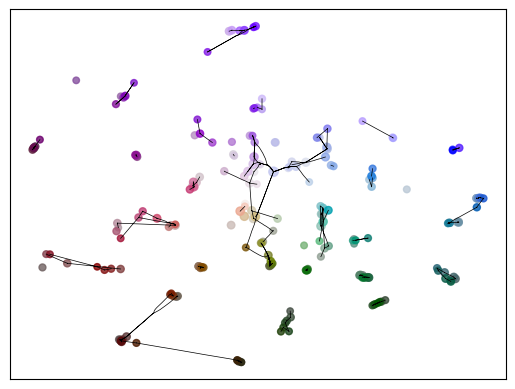

In [35]:
tm.plotting.centroid_datamap(mapper)

The optional `ax` parameter can be passed to add a centroid datamap to an existing matplotlib axis. In particular, the centroid_datamap is designed to be added on top of a DataMapPlot plot of the cluster points, if one so desires:

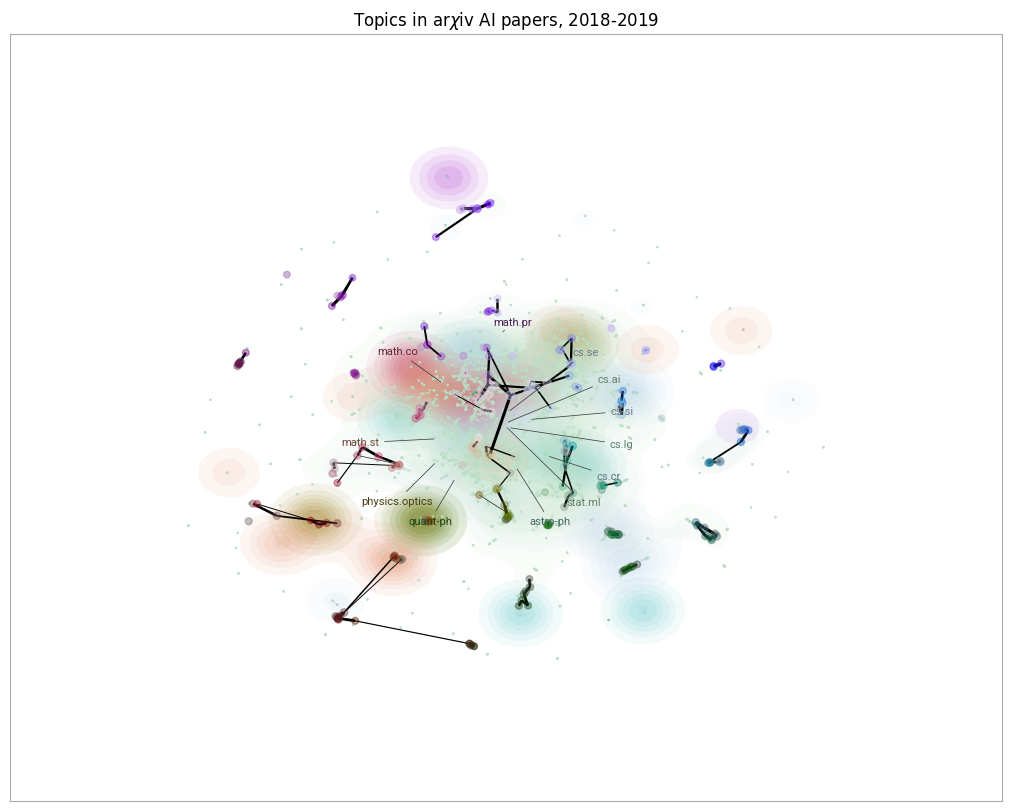

In [36]:
import datamapplot as dmp

fig, ax = dmp.create_plot(
    mapper.data,
    df['arxiv'].to_list(),
)
tm.plotting.centroid_datamap(mapper, ax=ax, bundle=False)
fig.set_figwidth(10)
fig.set_figheight(8)
ax.set_title("Topics in ar$\chi$iv AI papers, 2018-2019")
plt.show()

By default, the centroid datamap matches colours with the temporal plot, to make it easier to relate the plots when viewing them side-by-side. To help convey the time information, vertices which correspond to earlier slices in the graph have their colour desaturated. This is a very subtle effect, so if you want to make the order of the vertices more obvious you can pass the option `node_colouring = 'override'`. This overrides the datamapplot colours, instead colouring vertices from dark to light as you move from the beginning to end of the time range.

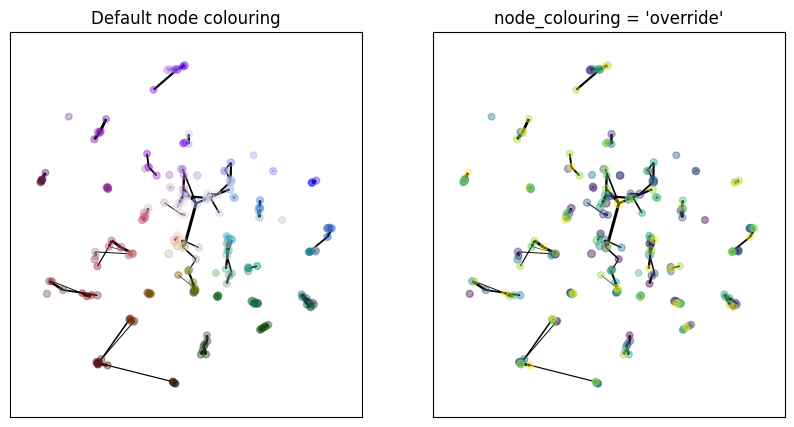

In [37]:
fig, (ax1, ax2) = plt.subplots(1,2)

tm.plotting.centroid_datamap(
    mapper,
    ax=ax1,
    node_colouring = 'desaturate',
    bundle=False
)
ax1.set_title("Default node colouring")
tm.plotting.centroid_datamap(
    mapper,
    ax=ax2,
    node_colouring = 'override',
    bundle=False,
)
ax2.set_title("node_colouring = 'override'")
fig.set_figwidth(10)
fig.set_figheight(5)
plt.show()